# How to vibecode your data scraping methodology with GPT et Codex

> **This notebook presents AI-assisted ways of developing web scraping methods in different contexts (API, SPARQL, OAI-PMH repository, etc.)**

Notebook objective: show how to use GPT/Codex to progressively arrive at a clean scraping method, without starting by writing code.
The idea is to demonstrate a method: make the right diagnosis, choose the right data access, ask the AI to verify its assumptions, and only then automate if necessary.
This material is designed for a beginner user: we start with simple prompts, read the response, and decide what to do.

## Définitions

**Vibe coding:**

The term "vibe coding" is a concept that emerged alongside the creation and widespread adoption of major generative AI models such as ChatGPT, Claude, Gemini, DeepSeek, etc.
This term means that a person can code by relying almost entirely on AI, to the point of no longer writing a single line themselves or having to run the code. Indeed, Codex can execute scripts on your computer.

Ce terme signifie qu'une personne peut coder en s'appuyant quasi intégralement sur l'IA, au point de ne plus écrire soit-même aucune ligne et de ne plus devoir exécuter le code. En effet, Codex peut exécuter des scripts sur votre ordinateur.

**Scrapping:**

The term "scraping" refers to a technique for retrieving data from a website.

**API:**

An API is an access point provided by a site for retrieving data. If the site has an API, we can make our requests over HTTP. This is often the cleanest solution, because the data is already organized.

**HTTP requests:**


An HTTP request consists of asking a web server for a page or data. In scraping, HTTP requests are often used to retrieve an HTML page, a JSON file, an XML file, or metadata.

**BeautifulSoup:**

[BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/) is a Python library that allows you to read the HTML of a web page and extract certain information from it. It's used when the data is already present in the page and there's no need to click or scroll.

**Selenium:**

[Selenium](https://pypi.org/project/selenium/) allows you to control a browser using Chrome Driver. It's useful when data appears after an interaction: click, form, scroll, JavaScript loading, login, etc.
Selenium requires knowing where the data you want to scrape is located on the page. For example, if you want to scrape authors with Selenium, you need to be able to locate the element on the page, sometimes using an XPath.
That said, Selenium is quite unstable, but it lets you scrape data when nothing else works. The site may not have an API, and HTTP requests may not work.

**Cookies:**

It's also important to know whether the data you want to scrape is only accessible when logged into a website. In such cases, you need to save the cookies from your first login to the site.

**XPath:**

An XPath is a path that precisely designates an element within an HTML page. For example, to retrieve an author with Selenium, you can use an XPath that points to the element where the author's name appears.

**Retry delay and rate limit:**

It's necessary to build in retry delays to avoid being rate limited. This means leaving pauses between requests and planning to retry later if the site temporarily blocks requests.

**Firecrawl:**

Firecrawl is a tool that can help retrieve the content of web pages and turn it into more easily usable data.

**Scrapy:**

Scrapy is a Python framework specialized in scraping. It's very useful for crawling many pages, but it's more complex for a beginner to get to grips with than BeautifulSoup.

## How to easily install Codex

For a beginner, the simplest approach is to use the Codex application (https://openai.com/fr-FR/codex/):

1. Download and install the Codex application for Windows or macOS.
2. Log in with your ChatGPT account or an OpenAI API key.
3. Choose the project folder.
   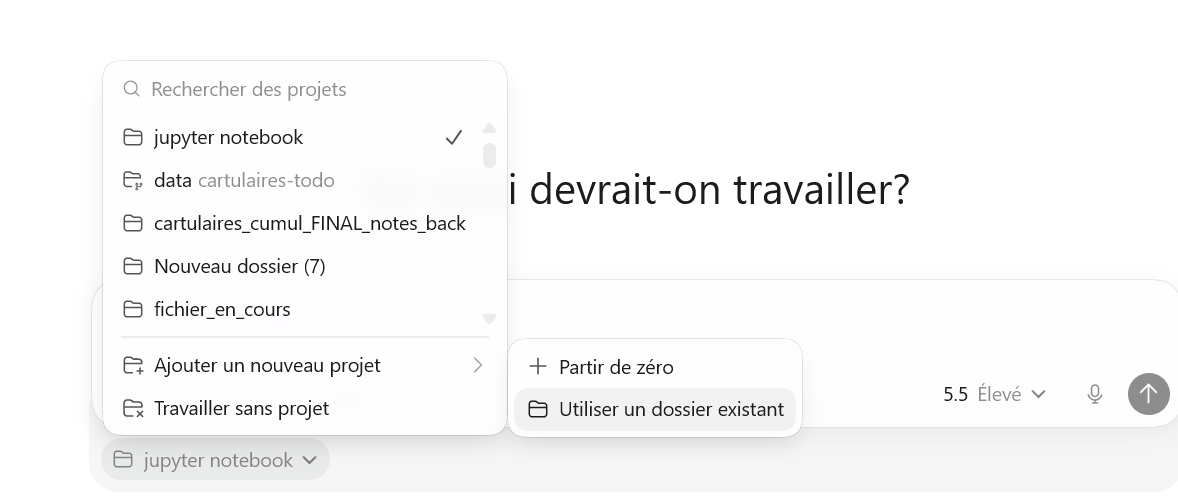
   You can then choose a folder.
   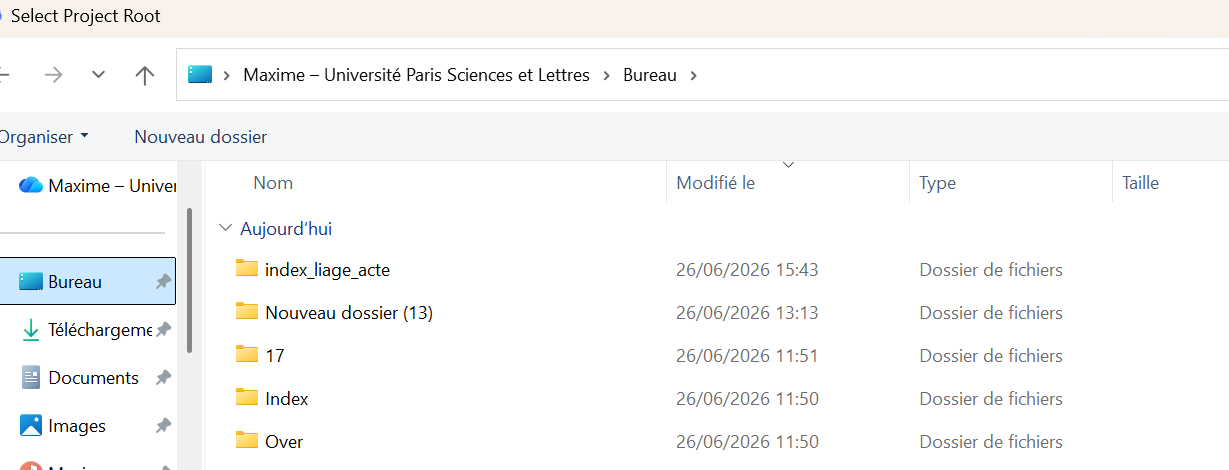  
4. Give Codex full access.

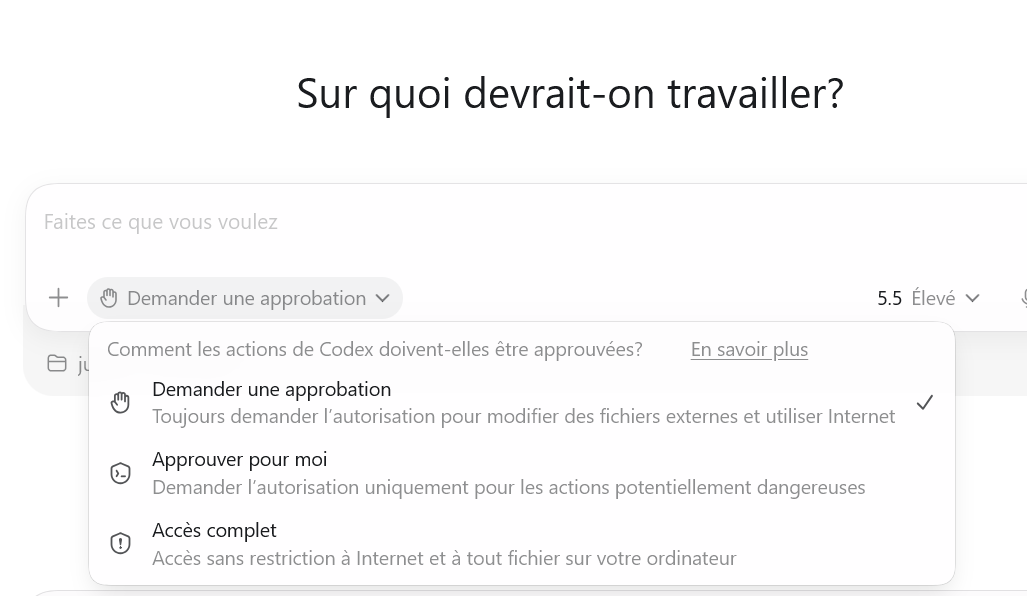
 


## Our prompt

I want to retrieve [your data type] images from this URL [replace the URL with your site]: [https://www.persee.fr/doc/dirht_0073-8212_1976_cat_12_3].
Before proposing any code, help me choose the simplest, most stable, and cleanest scraping method.

First check whether there is:
* an official API;
* an OAI-PMH repository;
* a SPARQL endpoint;
* a CSV, JSON, XML, RDF export, or an official download;
* IIIF access if I want to retrieve images or digitized documents.

If no official access exists, then check:
* whether the data is present directly in the page's HTML;
* whether it is loaded via JavaScript;
* whether it requires logging in, cookies, a click, a scroll, or a form.

Rank the possible methods from most reliable to most fragile:
* API or official access;
* OAI-PMH / SPARQL / data export;
* simple HTTP requests;
* BeautifulSoup;
* Selenium only if necessary;
* Firecrawl;
* Scrapy.
  
Explain to me why you're choosing this method, describe the risks associated to it, and tell me what would be the first small test step before automating.

## Practical Use Case: Retrieving Data from Persée

We'll try to retrieve images from Persée based on a URL.

Here is Codex's response to our prompt:
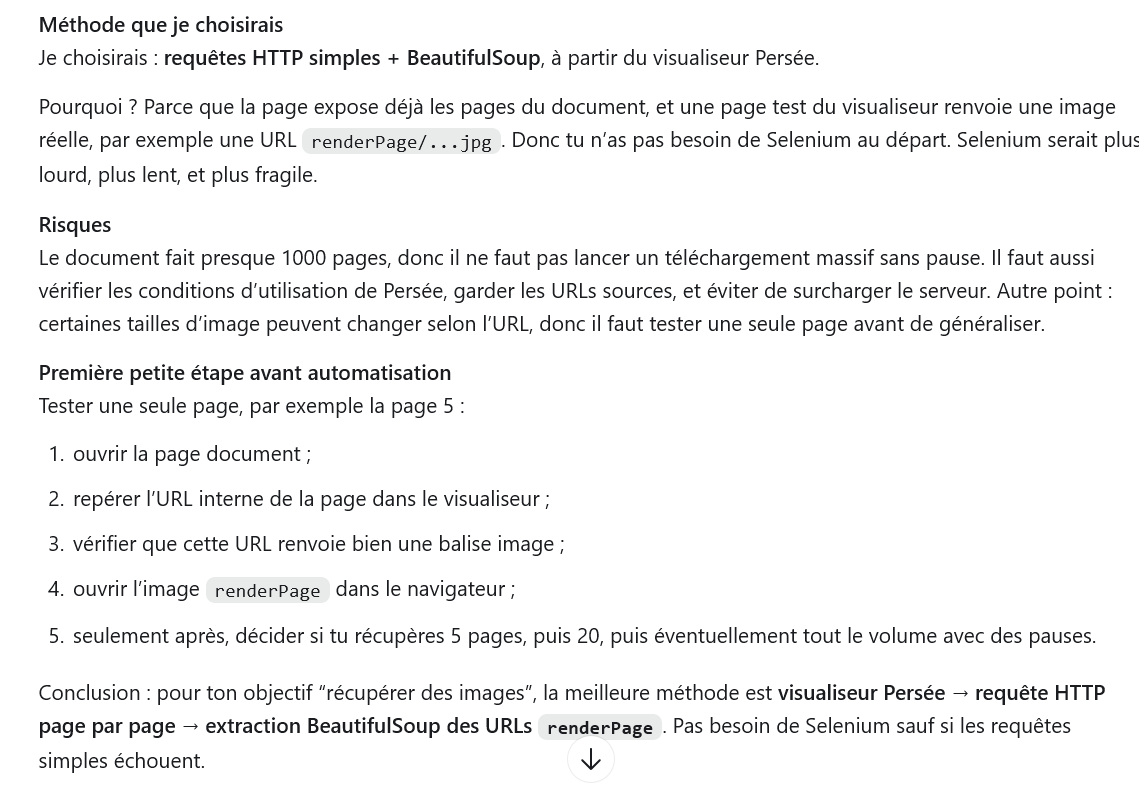

And here's the result after asking it in a prompt to use the most optimal method.
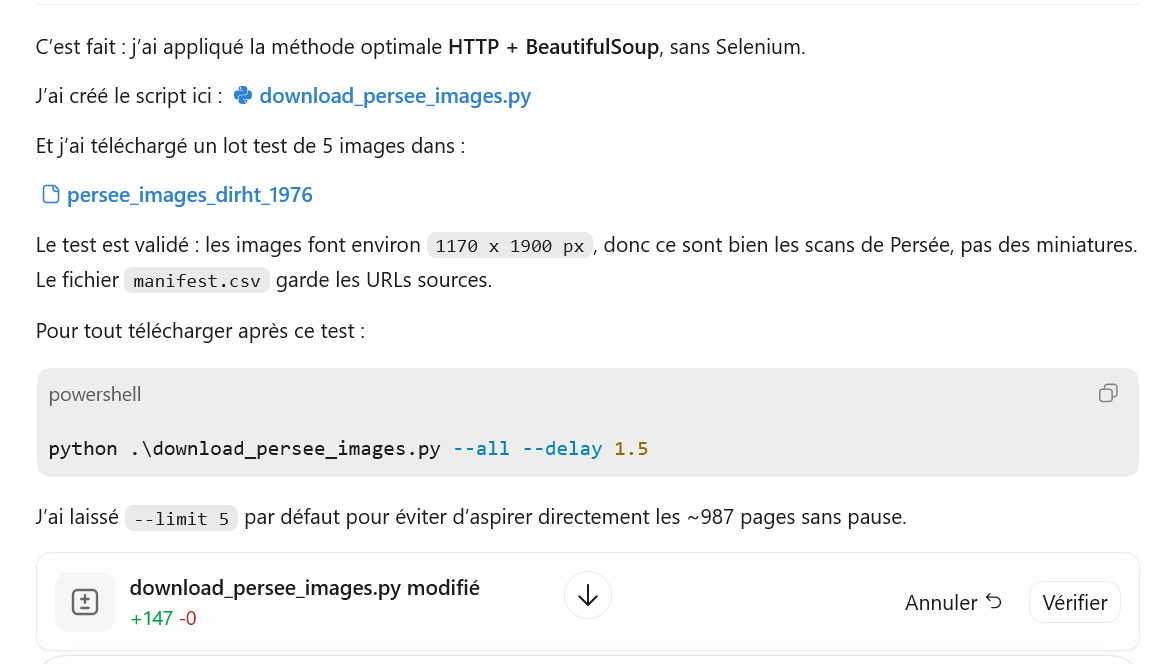

In 5 minutes, we were able to retrieve our data very easily.

## SPARQL Use Case: Querying Persée.

Prompt : 

I want to use the Data Persée SPARQL endpoint to enrich a document with new metadata.
Based on this resource: https://www.persee.fr/doc/dirht_0073-8212_1976_cat_12_3

Help me look for:
- the title;
- bibliographical references;
- authors and contributors;
- their autority identifiers;
- other documents linked to the same author;
- the document collection;
- other volumes from the same collection;
- the date, language, license, and publisher.

Result:

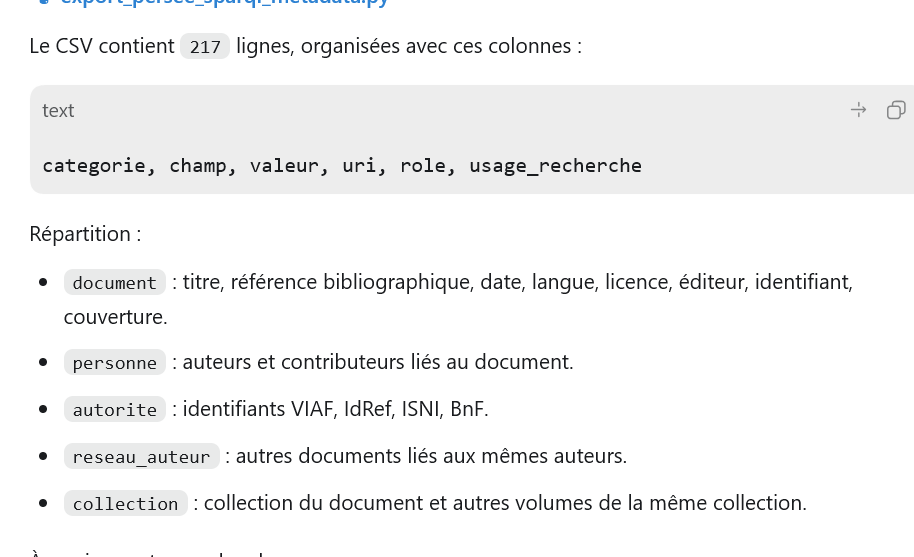

Codex found the various metadata present on Persée and put it into a CSV file.
It's also possible to harvest metadata from a collection on Nakala using the OAI-PMH protocol.

## OAI-PMH Use Case: Querying Nakala.

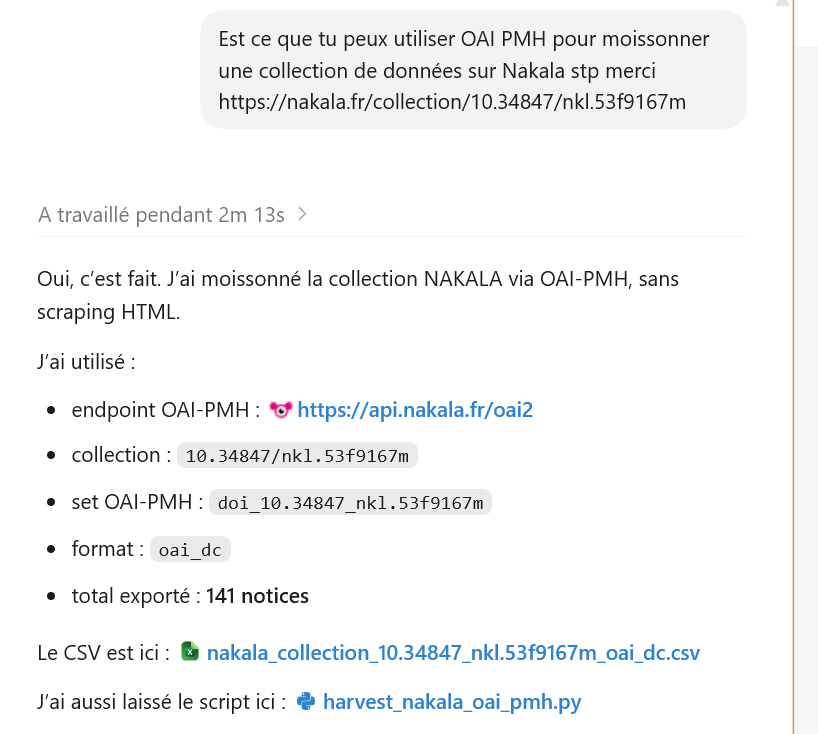

You can also query Nakala's API to obtain metadata in a CSV file.

## Quick Decision Sheet

| Situation | Method to Ask GPT For | Why |
|---|---|---|
| Structured bibliographic metadata | OAI-PMH | Stable, official, designed for harvesting |
| Relationships between authors, places, journals, concepts | SPARQL | Allows querying a data graph |
| Table or list already visible in the HTML | BeautifulSoup | Simple, readable, not very fragile |
| Results loaded after a click, scroll, or dynamic filter | Selenium | Allows reproducing human navigation |
| PDFs, images, or documents | Official API | Allows retrieving images |

## Best Practices

- Start small: one page, ten results, a single field.
- Keep the source URLs.
- Respect the site's terms of use.
- Add pauses if automating multiple requests.
- Don't use Selenium if an API or a simple HTML page is enough.
- Ask GPT to explain the method before generating code.

## Conclusion

It's very easy to scrape data through vibe coding. Codex lets a user get their results directly without needing to write code or run a script.